In [2]:
# Biblioteki
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets

import keras

from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Flatten
from tensorflow.keras import layers, models
from keras.src import optimizers

import seaborn as sns
import plotly.graph_objects as go
from sklearn import metrics

In [3]:
# Pobieramy zbiór danych CIFAR10 i dzielimy go na zbiór uczący i testowy
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normujemy dane
train_images, test_images = train_images / 255.0, test_images / 255.0

In [4]:
#Jaki wymiar mają dane
print(train_images.shape)
print(test_images.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [5]:
# etykiety klas danych CIFAR10
nazwy_etykiet = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
def rysuj_wyniki(model, historia):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Ocena modelu na zbiorze testowym
    test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=1)
    print(f"Dokładność na zbiorze testowym: {test_accuracy:.4f}")
    print(f"Wartość funkcji straty: {test_loss:.4f}")

    axes[0].plot(historia.history['accuracy'], label='Treningowy', marker="o")
    axes[0].plot(historia.history['val_accuracy'], label='Walidacyjny', marker="v")
    axes[0].axhline(y=test_accuracy, color='red', linestyle='--', linewidth=2,
                   label=f'Testowy: {test_accuracy:.3f}')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('Dokładność')
    axes[0].set_ylim([0, 1])
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left')
    axes[0].set_xticks(range(len(historia.history['accuracy'])))


    # Predykcje na zbiorze testowym
    pred = model.predict(test_images, verbose=0)
    pred_etykiety = np.argmax(pred, axis=1)

    # Macierz pomyłek
    cm = metrics.confusion_matrix(test_labels, pred_etykiety)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nazwy_etykiet,
                yticklabels=nazwy_etykiet,
                ax=axes[1])

    axes[1].set_title('Macierz pomyłek')
    axes[1].set_xlabel('Przewidywane etykiety')
    axes[1].set_ylabel('Prawdziwe etykiety')

    plt.tight_layout()
    plt.show()

# Bazowa sieć CNN

In [ ]:
# Tworzymy bazową sieć CNN
# Dwie warstwy splotowe (po 32 filtry 3x3 z funkcją aktywacji ReLU)
# Po każdej warstwie splotowej Max Pooling 2x2

# Na sam koniec przekazujemy dane do gęstej sieci neuronowej
# warstwa gęsta (64 neurony z funkcją aktywacji ReLU)
# warstwa gęsta (wyjscie, 10 neuronów z funkcją aktywacji softmax)

# Rozmiar batcha to 128, liczba epok to 15

cnn_base = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(32, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_base.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Podsumowanie modelu
cnn_base.summary()

# Trening modelu
cnn_base_hist = cnn_base.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,586 (330.41 KB)

 Trainable params: 84,586 (330.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.3220 - loss: 1.8680 - val_accuracy: 0.4976 - val_loss: 1.4148
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5157 - loss: 1.3586 - val_accuracy: 0.5600 - val_loss: 1.2656
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5679 - loss: 1.2238 - val_accuracy: 0.5942 - val_loss: 1.1835
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6076 - loss: 1.1242 - val_accuracy: 0.6116 - val_loss: 1.1001
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6325 - loss: 1.0548 - val_accuracy: 0.6350 - val_loss: 1.0469
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6488 - loss: 1.0077 - val_accuracy: 0.6548 - val_loss: 1.0060
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6643 - loss: 0.9713 - val_accuracy: 0.6530 - val_loss: 0.9954
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6834 - loss: 0.9148 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6905 - loss: 0.9197
Dokładność na zbiorze testowym: 0.6885
Wartość funkcji straty: 0.9305


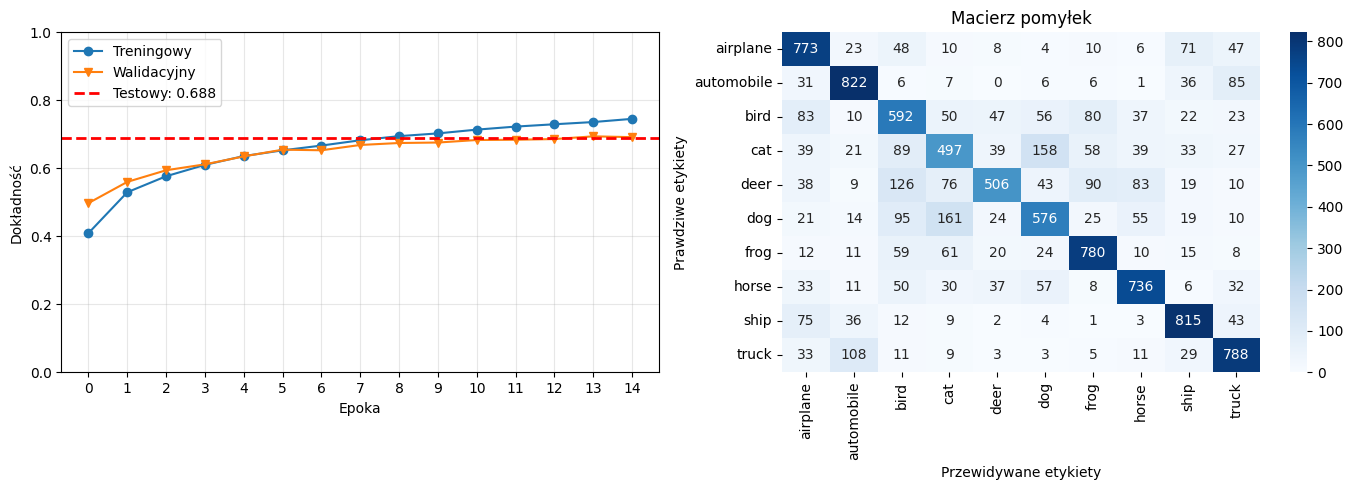

In [ ]:
rysuj_wyniki(model = cnn_base, historia = cnn_base_hist)

Uzyskaliśmy dokładność na poziomie około 68%.

Sieć radzi sobie najgorzej w rozpoznawaniu psów i kotów. Najczęściej myli te dwie kategorie. Świadczy o tym macierz pomyłek.


# Zwiększnie liczby filtrów w warstwie splotowej
Przetestujmy, jaki wpływ na dokładność ma zmiana liczby filtrów w warstwach splotowych.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,794 (1.70 MB)

 Trainable params: 446,794 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3366 - loss: 1.8352 - val_accuracy: 0.5314 - val_loss: 1.3112
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5520 - loss: 1.2660 - val_accuracy: 0.5848 - val_loss: 1.1783
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6173 - loss: 1.0932 - val_accuracy: 0.6296 - val_loss: 1.0483
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6460 - loss: 1.0111 - val_accuracy: 0.6320 - val_loss: 1.0430
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6753 - loss: 0.9373 - val_accuracy: 0.6722 - val_loss: 0.9381
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6977 - loss: 0.8745 - val_accuracy: 0.6898 - val_loss: 0.9012
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7253 - loss: 0.8057 - val_accuracy: 0.6842 - val_loss: 0.9175
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7351 - loss: 0.7665 - val_acc

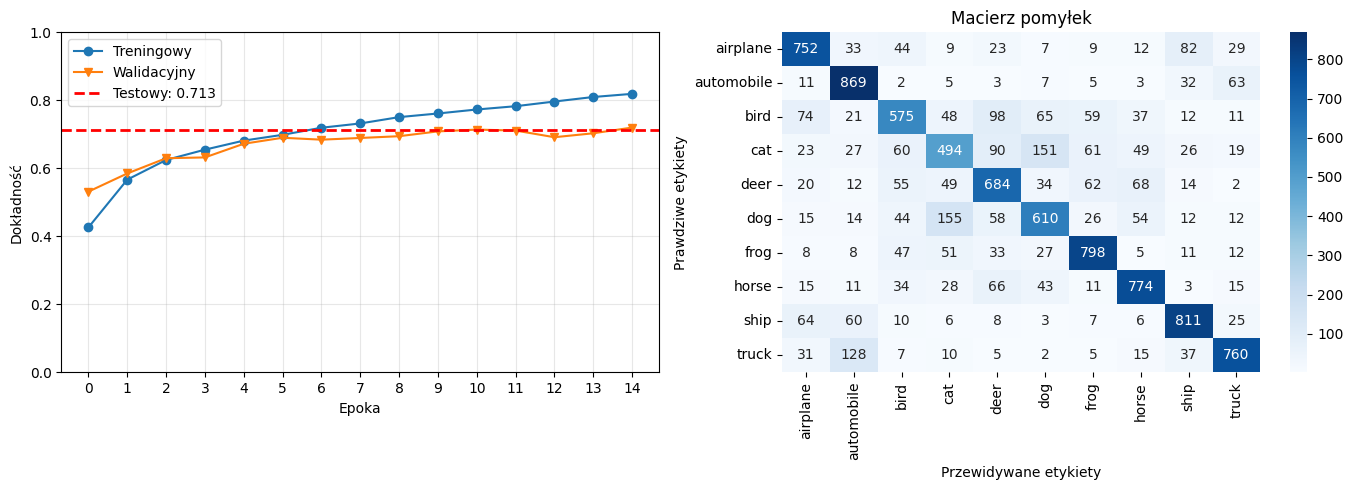

In [14]:
# Zwiększenie liczby filtrów
cnn_more_kernels = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(128, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(128, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_more_kernels.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Podsumowanie modelu
cnn_more_kernels.summary()

# Trening modelu
cnn_more_kernels_hist = cnn_more_kernels.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_more_kernels, historia = cnn_more_kernels_hist)

Pomimo 5-krotnego zwiększenia liczby parametrów w modelu (względem sieci bazowej), wynik wzrósł o zaledwie 2 punkty procentowe. Zatem, nie jest to zadowalająca poprawa, biorąc pod uwagę znaczne skomplikowanie modelu.

Sprawdźmy zatem, czy możemy zoptymalizować sieć, nie tracąc przy tym na dokładności klasyfikacji, poprzez zmniejszenie liczby filtrów.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,346 (157.60 KB)

 Trainable params: 40,346 (157.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2878 - loss: 1.9470 - val_accuracy: 0.4788 - val_loss: 1.4524
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4863 - loss: 1.4331 - val_accuracy: 0.5272 - val_loss: 1.3430
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5327 - loss: 1.3130 - val_accuracy: 0.5624 - val_loss: 1.2276
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5647 - loss: 1.2343 - val_accuracy: 0.5864 - val_loss: 1.1906
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5896 - loss: 1.1706 - val_accuracy: 0.5910 - val_loss: 1.1740
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6033 - loss: 1.1325 - val_accuracy: 0.6158 - val_loss: 1.1306
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6145 - loss: 1.0951 - val_accuracy: 0.6286 - val_loss: 1.0931
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6283 - loss: 1.0617 - val_accuracy: 0

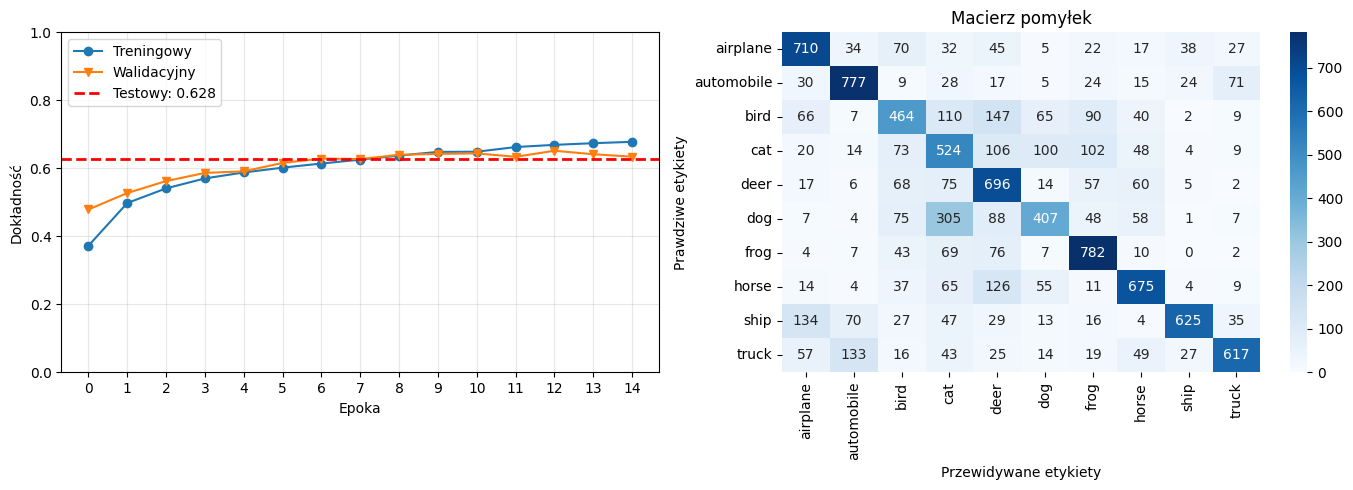

In [16]:
# Zmniejszenie liczby filtrów
cnn_more_kernels = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(16, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(16, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_more_kernels.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Podsumowanie modelu
cnn_more_kernels.summary()

# Trening modelu
cnn_more_kernels_hist = cnn_more_kernels.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_more_kernels, historia = cnn_more_kernels_hist)

Model ma teraz 2 razy mniej parametrów niż bazowa sieć. Obserwujemy jednak znacznie większy spadek dokładności (ok. 63%). Zatem 32 filtry w warstwie wydają się być rozsądną wartością hiperparametru.

### Dodanie nowych warstw splotowych

Spróbujmy poprawić dokładność rozpoznawania obrazów przez model, dodając nowe warstwy splotowe.

In [ ]:
# Zwiększenie liczby warstw splotowych - łącznie 3 warstwy
cnn_more_layers = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),

         layers.Conv2D(32, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),

         layers.Conv2D(32, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),

         layers.Conv2D(32, (3, 3), activation="relu"),
         layers.MaxPooling2D((2, 2)),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_more_layers.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Podsumowanie modelu
cnn_more_layers.summary()

# Trening modelu
cnn_more_layers_hist = cnn_more_layers.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,298 (110.54 KB)

 Trainable params: 28,298 (110.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2501 - loss: 2.0041 - val_accuracy: 0.4174 - val_loss: 1.5786
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4439 - loss: 1.5220 - val_accuracy: 0.4944 - val_loss: 1.3977
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5087 - loss: 1.3537 - val_accuracy: 0.5392 - val_loss: 1.2902
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5452 - loss: 1.2683 - val_accuracy: 0.5580 - val_loss: 1.2470
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5741 - loss: 1.1979 - val_accuracy: 0.5864 - val_loss: 1.1606
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5938 - loss: 1.1473 - val_accuracy: 0.5910 - val_loss: 1.1556
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6026 - loss: 1.1159 - val_accuracy: 0.6084 - val_loss: 1.1052
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6211 - loss: 1.0723 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6572 - loss: 0.9799
Dokładność na zbiorze testowym: 0.6582
Wartość funkcji straty: 0.9798


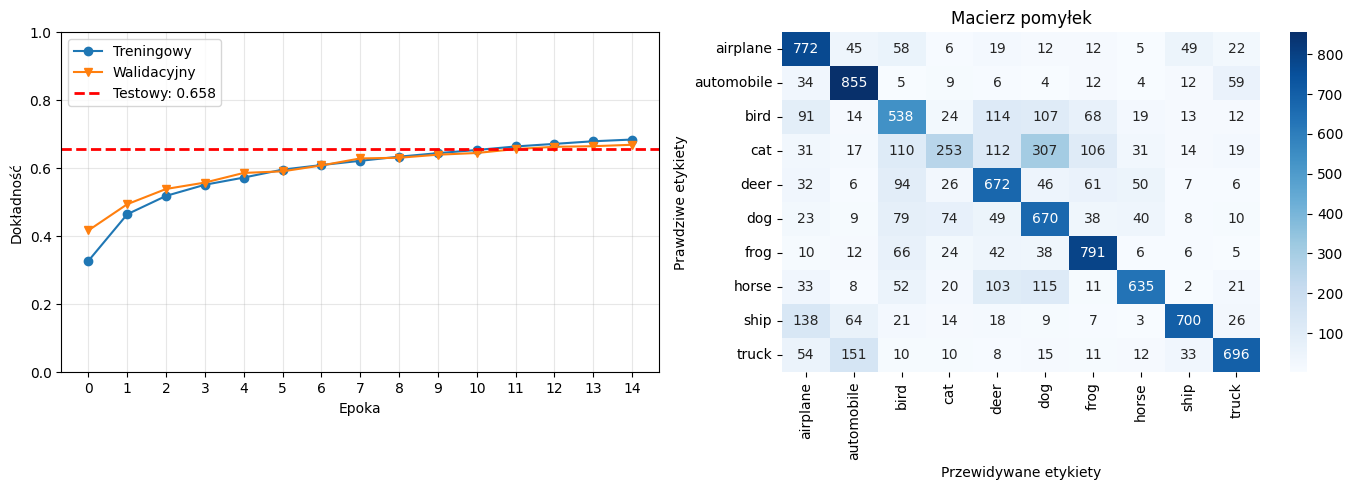

In [ ]:
rysuj_wyniki(model = cnn_more_layers, historia = cnn_more_layers_hist)

Dodanie kolejnej warstwy splotowej pogorszyło wynik (względem bazowego modelu). Jest on jednak lepszy, niż w przypadku 2 warstw po 16 filtrów każda (pomimo tego że model z mniejszą liczbą filtrów ma więcej parametrów do wytrenowania).

# Dodanie paddingu
Problemem może być zbyt szybkie zmniejszanie się danych wejściowych do następnej warstwy. Sprawdźmy, czy dodanie paddingu do warstw splotowych poprawi jakość modelu.

In [ ]:
# Dodanie paddingu
# padding = "same" nie zmienia wymiaru wyjścia względem wymiarów wejścia

cnn_padding = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_padding.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Podsumowanie modelu
cnn_padding.summary()

# Trening modelu
cnn_padding_hist = cnn_padding.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,930 (554.41 KB)

 Trainable params: 141,930 (554.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.2997 - loss: 1.9045 - val_accuracy: 0.5180 - val_loss: 1.3584
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5305 - loss: 1.3332 - val_accuracy: 0.5606 - val_loss: 1.2385
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5750 - loss: 1.1900 - val_accuracy: 0.5984 - val_loss: 1.1626
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6144 - loss: 1.0977 - val_accuracy: 0.6254 - val_loss: 1.0788
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6449 - loss: 1.0242 - val_accuracy: 0.6502 - val_loss: 1.0039
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6650 - loss: 0.9683 - val_accuracy: 0.6568 - val_loss: 0.9856
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6888 - loss: 0.9060 - val_accuracy: 0.6712 - val_loss: 0.9596
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6917 - loss: 0.8884 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7054 - loss: 0.8789
Dokładność na zbiorze testowym: 0.6976
Wartość funkcji straty: 0.8936


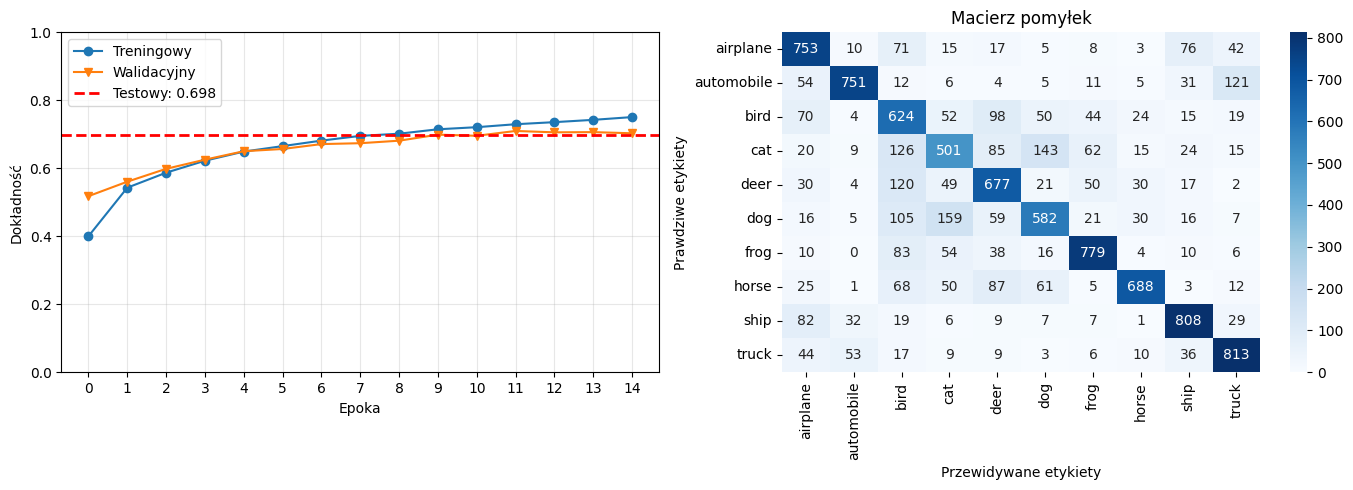

In [ ]:
rysuj_wyniki(model = cnn_padding, historia = cnn_padding_hist)

Dokładność, względem modelu bazowego, nieznacznie wzrosła. Nie jest to jednak znacząca poprawa. Wzrosła także liczba parametrów.

Spróbujmy zwiększyć liczbę warstw i filtrów wraz z zastosowaniem paddingu

In [17]:
cnn_more_filters_padding = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_more_filters_padding.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Podsumowanie modelu
cnn_more_filters_padding.summary()

# Trening modelu
cnn_more_filters_padding_hist = cnn_more_filters_padding.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,890 (370.66 KB)

 Trainable params: 94,890 (370.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3019 - loss: 1.8982 - val_accuracy: 0.4642 - val_loss: 1.4896
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5166 - loss: 1.3502 - val_accuracy: 0.5838 - val_loss: 1.1849
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5930 - loss: 1.1559 - val_accuracy: 0.6314 - val_loss: 1.0658
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6363 - loss: 1.0403 - val_accuracy: 0.6564 - val_loss: 0.9975
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6691 - loss: 0.9548 - val_accuracy: 0.6874 - val_loss: 0.9296
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6904 - loss: 0.8885 - val_accuracy: 0.7036 - val_loss: 0.8843
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7135 - loss: 0.8267 - val_accuracy: 0.7110 - val_loss: 0.8466
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7209 - loss: 0.7951 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7190 - loss: 0.8514
Dokładność na zbiorze testowym: 0.7167
Wartość funkcji straty: 0.8575


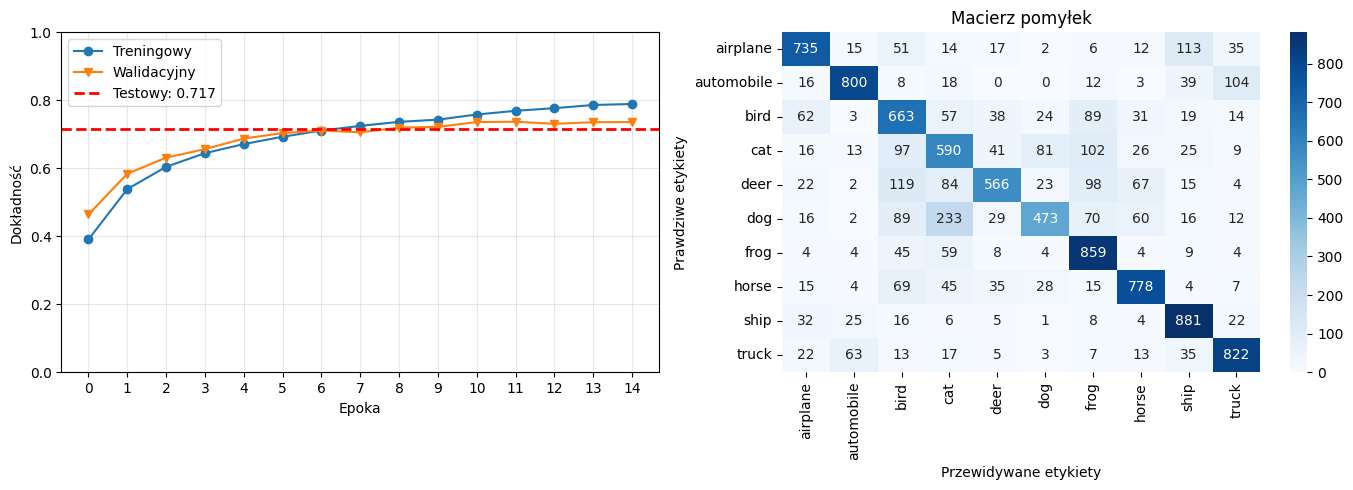

In [18]:
rysuj_wyniki(model = cnn_more_filters_padding, historia = cnn_more_filters_padding_hist)

Uzyskaliśmy dokładność powyżej 70 % przy niewiele większej liczbie parametrów niż dla modelu bazowego. Zatem padding, wraz ze zwiększeniem liczby warstw splotowych, poprawił dokładność sieci.

# Zastosowanie Batch Normalization

Nawet jeżeli znormalizujemy dane wejściowe, to poprzez użycie nieliniowych funkcji aktywacji, odpowiedzi warst już nie muszą być znormalizowane, a one stanowią dane dla kolejnych warst.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,402 (372.66 KB)

 Trainable params: 95,146 (371.66 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4209 - loss: 1.6481 - val_accuracy: 0.3368 - val_loss: 2.1871
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6336 - loss: 1.0279 - val_accuracy: 0.5556 - val_loss: 1.2670
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7028 - loss: 0.8524 - val_accuracy: 0.6084 - val_loss: 1.2319
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7436 - loss: 0.7263 - val_accuracy: 0.6004 - val_loss: 1.2840
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7786 - loss: 0.6342 - val_accuracy: 0.7056 - val_loss: 0.8652
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7940 - loss: 0.5723 - val_accuracy: 0.7166 - val_loss: 0.8356
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8213 - loss: 0.5048 - val_accuracy: 0.7234 - val_loss: 0.8284
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8445 - loss: 0.4415 - val_accuracy: 

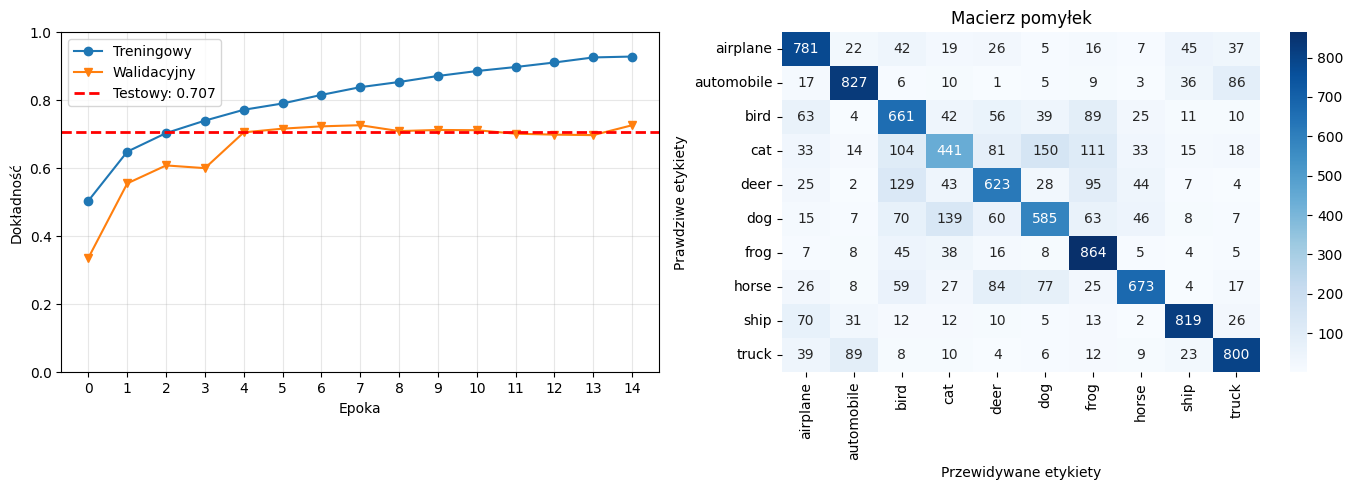

In [19]:
# Dodanie Batch Normalization - tylko w CNN
# Stosujemy BN po warstwie splotowej

cnn_BN = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN.summary()

# Trening modelu
cnn_BN_hist= cnn_BN.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN, historia = cnn_BN_hist)

Obserwujemy wysoką dokładność na zbiorze treningowym (ponad 90% po 15 epokach) oraz znacznie mniejszą na zbiorze walidacyjnym (proces uczenia zatrzymuje się po kilku pierwszych epokach) i testowym. Widoczne jest zatem przeuczenie modelu. Konieczne może być zatem dodanie Dropout'u.

Widoczne jest jednak znaczne przyspieszenie procesu uczenia i dokładności (przynajmniej na zbiorze testowym), co jest spodziewanym wynikiem przy stosowaniu Batch Normalization.

# Zastosowanie Dropout
Dropout powoduje losowe "wyłączanie" neuronów (z pewnym prawdopodobieństwem) podczas procesu uczenia sieci.

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,402 (372.66 KB)

 Trainable params: 95,146 (371.66 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.2993 - loss: 2.0079 - val_accuracy: 0.1366 - val_loss: 4.8089
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5009 - loss: 1.3801 - val_accuracy: 0.5444 - val_loss: 1.3047
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5645 - loss: 1.2166 - val_accuracy: 0.5510 - val_loss: 1.2910
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6050 - loss: 1.1104 - val_accuracy: 0.6008 - val_loss: 1.1474
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6430 - loss: 1.0169 - val_accuracy: 0.5468 - val_loss: 1.3569
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6574 - loss: 0.9600 - val_accuracy: 0.6856 - val_loss: 0.8827
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6771 - loss: 0.9039 - val_accuracy: 0.6598 - val_loss: 0.9846
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6956 - loss: 0.8613 - val_accura

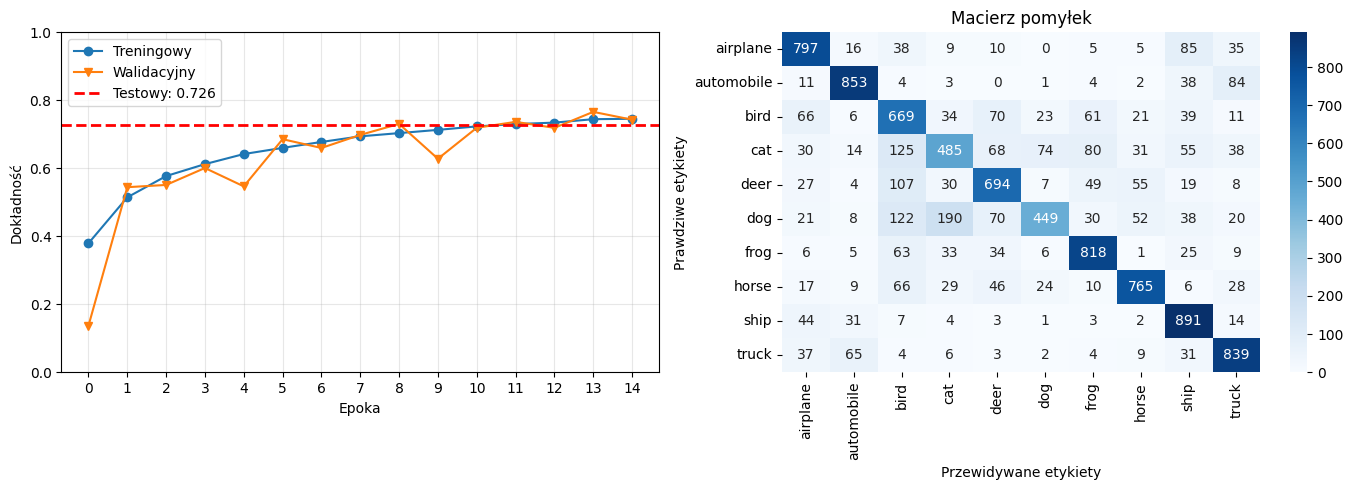

In [20]:
# Dodajemy Dropout po Pooling

cnn_BN_Drop = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.3),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.3),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.3),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop.summary()

# Trening modelu
cnn_BN_Drop_hist= cnn_BN_Drop.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop, historia = cnn_BN_Drop_hist)

Po zastosowaniu Batch Normalization i Dropout uzyskaliśmy najlepszy wynik. Dodatkowo, dokładność na zbiorze treningowym i walidacyjnym są do siebie zbliżone. Udało się zatem wyeliminować przeuczenie modelu.
Dropout zmniejszył prędkość uczenia, dlatego konieczne może być zwiększenie liczby epok.

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,402 (372.66 KB)

 Trainable params: 95,146 (371.66 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3397 - loss: 1.9090 - val_accuracy: 0.1734 - val_loss: 3.1119
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5320 - loss: 1.3053 - val_accuracy: 0.4764 - val_loss: 1.4756
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5996 - loss: 1.1296 - val_accuracy: 0.6168 - val_loss: 1.0842
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6276 - loss: 1.0440 - val_accuracy: 0.6390 - val_loss: 1.0326
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6550 - loss: 0.9741 - val_accuracy: 0.6664 - val_loss: 0.9712
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6799 - loss: 0.9001 - val_accuracy: 0.6750 - val_loss: 0.9384
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6955 - loss: 0.8577 - val_accuracy: 0.4894 - val_loss: 1.7782
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7064 - loss: 0.8211 - val_accuracy: 

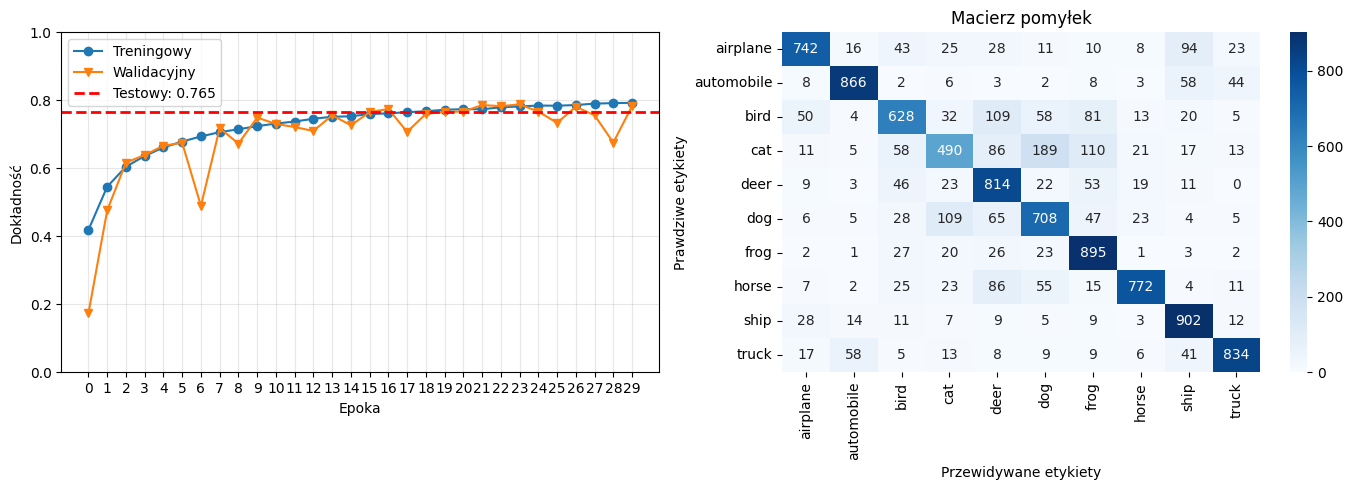

In [ ]:
# Dodajemy Dropout

cnn_BN_Drop = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.3),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.3),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.3),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop.summary()

# Trening modelu
cnn_BN_Drop_hist= cnn_BN_Drop.fit(train_images, train_labels,
                     epochs=30, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop, historia = cnn_BN_Drop_hist)

Przy zwiększeniu liczby epok do 30, można zaobserwować poprawę dokładności.
Jednak szybkość uczenia modelu jest bardzo mała, zatem dalsze zwiększanie liczby epok może nie przynieść istotnej poprawy dokładności.

# Zwiększenie prawdopodobieństwa na wyłączenie części neuronów

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,402 (372.66 KB)

 Trainable params: 95,146 (371.66 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2710 - loss: 2.1747 - val_accuracy: 0.1254 - val_loss: 4.6713
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4507 - loss: 1.5134 - val_accuracy: 0.3658 - val_loss: 1.9259
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5033 - loss: 1.3800 - val_accuracy: 0.4954 - val_loss: 1.4443
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5361 - loss: 1.2792 - val_accuracy: 0.5314 - val_loss: 1.3249
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5618 - loss: 1.2119 - val_accuracy: 0.5192 - val_loss: 1.3911
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5816 - loss: 1.1628 - val_accuracy: 0.5640 - val_loss: 1.2439
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5990 - loss: 1.1151 - val_accuracy: 0.4350 - val_loss: 1.8041
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6159 - loss: 1.0812 - val_accuracy: 

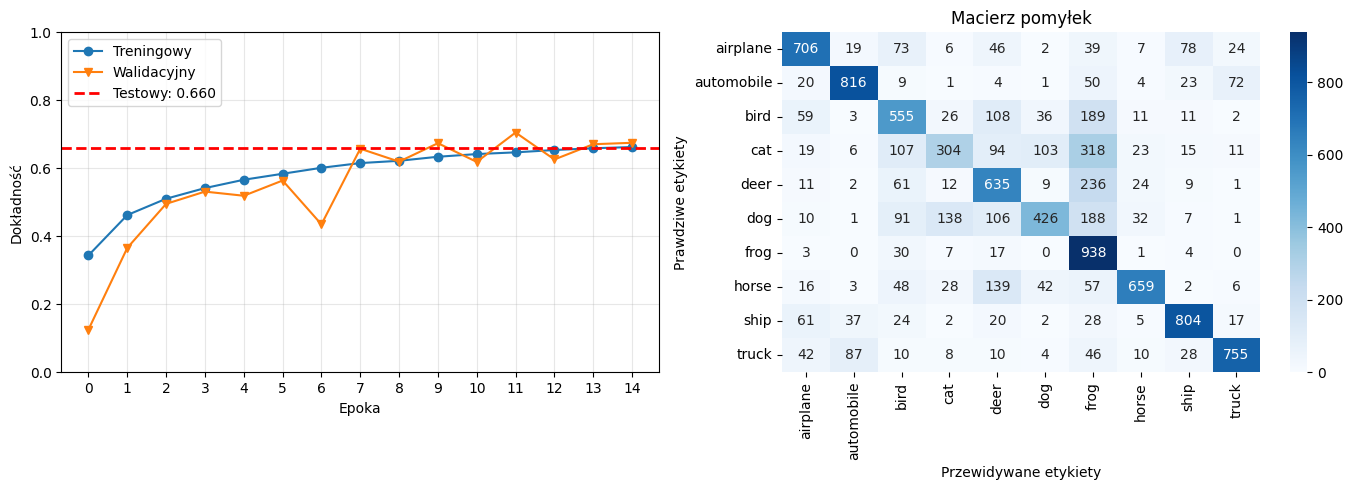

In [23]:
# Spróbujmy zwiększyć wartość prawdopodobieństwa na Dropout

cnn_BN_Drop_all = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.5),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.5),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.5),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop_all.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop_all.summary()

# Trening modelu
cnn_BN_Drop_all_hist= cnn_BN_Drop_all.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop_all, historia = cnn_BN_Drop_all_hist)

Zwiększenie wartości hiperparametru dla Dropout pogorszyło wynik.

# Dodanie Batch Normalization i Dropout do gęstych warstw sieci

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,658 (373.66 KB)

 Trainable params: 95,274 (372.16 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.3617 - loss: 1.8954 - val_accuracy: 0.2028 - val_loss: 2.3538
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5699 - loss: 1.2087 - val_accuracy: 0.5906 - val_loss: 1.1281
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6255 - loss: 1.0568 - val_accuracy: 0.6334 - val_loss: 1.0416
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6644 - loss: 0.9610 - val_accuracy: 0.6958 - val_loss: 0.8710
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6826 - loss: 0.8948 - val_accuracy: 0.6928 - val_loss: 0.8894
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7029 - loss: 0.8427 - val_accuracy: 0.6136 - val_loss: 1.1230
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7264 - loss: 0.7883 - val_accuracy: 0.7164 - val_loss: 0.8330
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7328 - loss: 0.7627 - val_accuracy: 

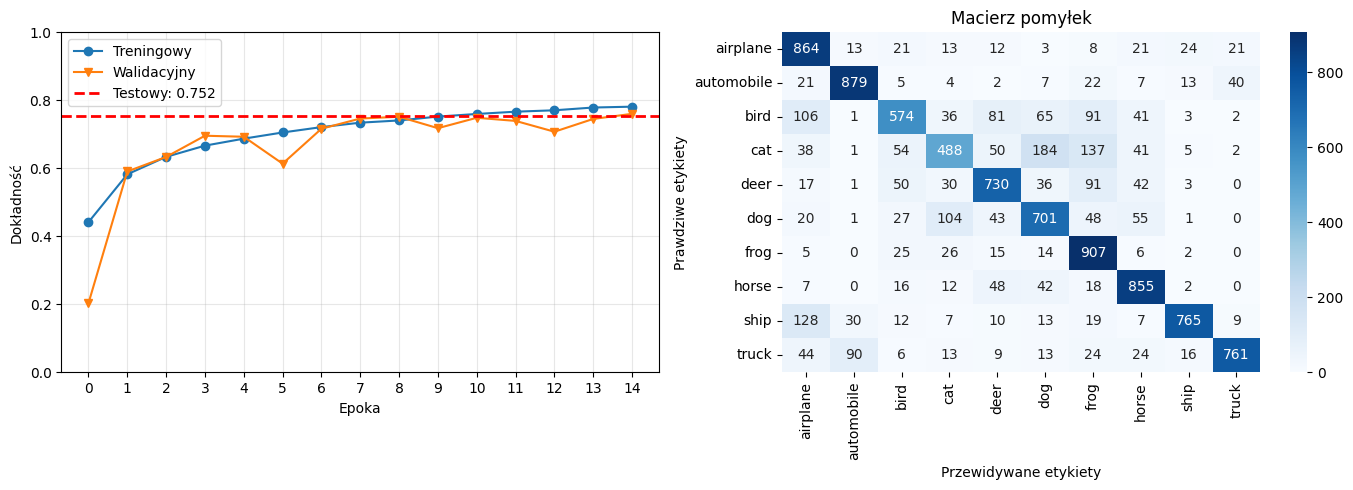

In [26]:
# Spróbujmy jeszcze dodać BN i Dropout do warstwy gęstej

# Zmniejszamy wartość Dropout w warstwach splotowych

cnn_BN_Drop_all = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop_all.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop_all.summary()

# Trening modelu
cnn_BN_Drop_all_hist= cnn_BN_Drop_all.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop_all, historia = cnn_BN_Drop_all_hist)

Zmniejszenie prawdopodobieństwa w warstwie Dropout oraz dodanie Batch Normalization i Dropout w warstwie gęstej, pozwoliło na uzyskanie stabilnego procesu uczenia i najlepszego do tej pory wyniku (w pierwszych 15 epokach).

# Zmiana rozmiaru batcha
Badamy wpływ rozmiaru porcji danych na dokładność klasyfikacji.

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,658 (373.66 KB)

 Trainable params: 95,274 (372.16 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.3050 - loss: 2.1190 - val_accuracy: 0.1126 - val_loss: 2.3864
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4968 - loss: 1.3953 - val_accuracy: 0.1234 - val_loss: 2.9135
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5682 - loss: 1.2085 - val_accuracy: 0.1858 - val_loss: 2.9726
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6113 - loss: 1.0953 - val_accuracy: 0.2712 - val_loss: 2.5865
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6348 - loss: 1.0348 - val_accuracy: 0.3062 - val_loss: 2.1880
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6577 - loss: 0.9594 - val_accuracy: 0.4252 - val_loss: 1.6834
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6770 - loss: 0.9158 - val_accuracy: 0.5342 - val_loss: 1.3144
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6946 - loss: 0.8644 - val_accuracy: 0.6608 -

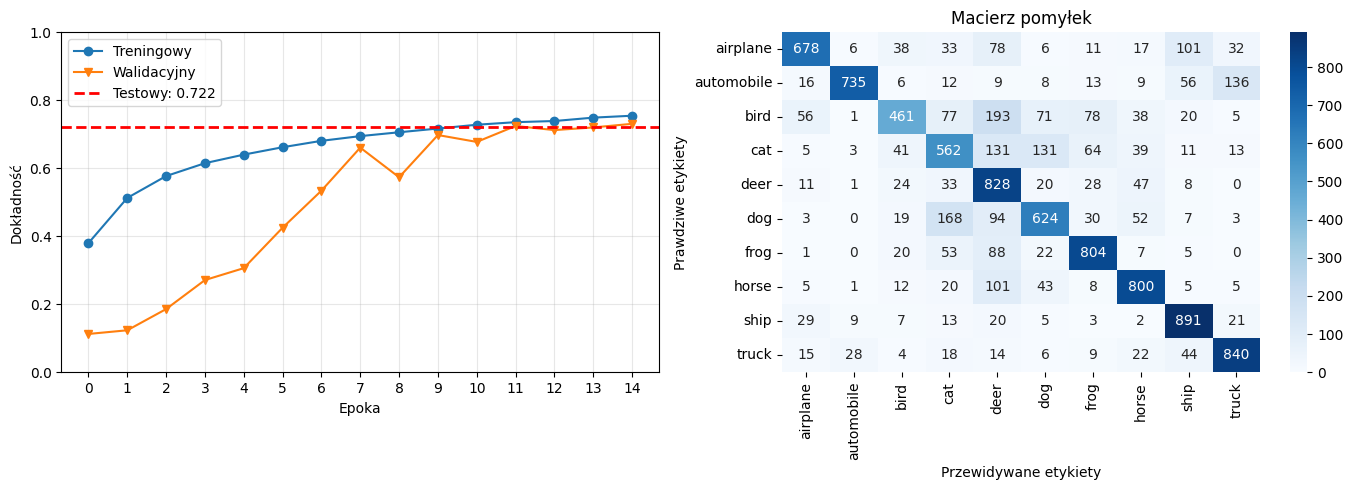

In [27]:
# Zwiększamy rozmiar batcha do 512
cnn_BN_Drop_all = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop_all.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop_all.summary()

# Trening modelu
cnn_BN_Drop_all_hist= cnn_BN_Drop_all.fit(train_images, train_labels,
                     epochs=15, batch_size=512,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop_all, historia = cnn_BN_Drop_all_hist)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,658 (373.66 KB)

 Trainable params: 95,274 (372.16 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.3156 - loss: 2.0946 - val_accuracy: 0.0976 - val_loss: 2.8924
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5042 - loss: 1.3760 - val_accuracy: 0.0976 - val_loss: 4.9952
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5789 - loss: 1.1899 - val_accuracy: 0.0976 - val_loss: 5.6496
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6214 - loss: 1.0707 - val_accuracy: 0.1006 - val_loss: 5.4248
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6515 - loss: 0.9909 - val_accuracy: 0.2070 - val_loss: 3.0437
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6712 - loss: 0.9366 - val_accuracy: 0.4374 - val_loss: 1.6473
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6844 - loss: 0.8976 - val_accuracy: 0.4826 - val_loss: 1.5763
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7023 - loss: 0.8435 - val_accuracy: 0.6440 -

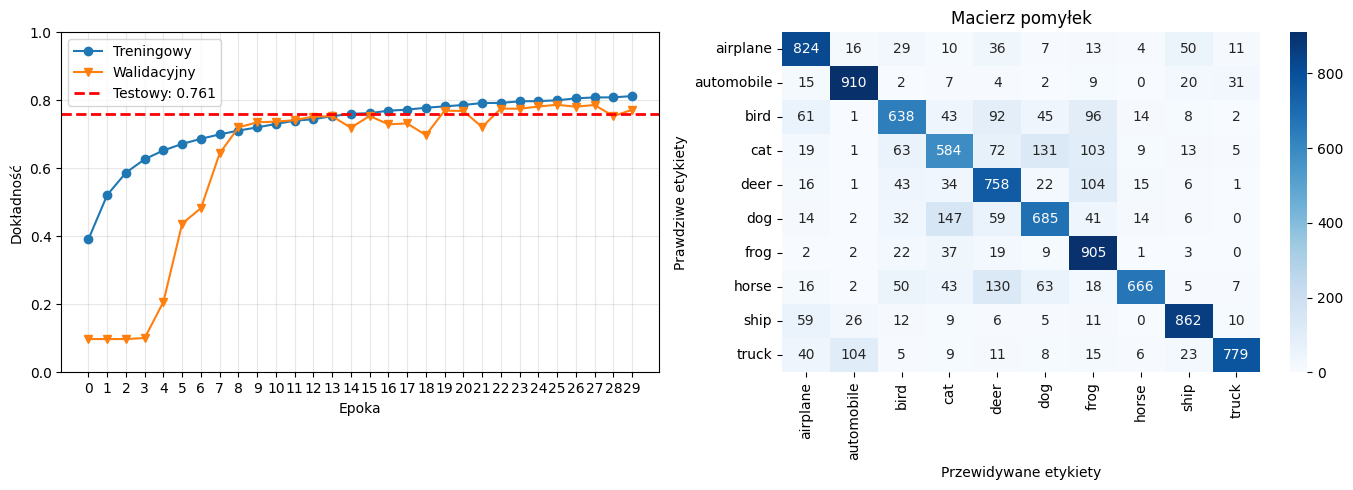

In [29]:
# Zwiększamy rozmiar batcha do 512 oraz liczbę epok do 30
cnn_BN_Drop_all = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop_all.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop_all.summary()

# Trening modelu
cnn_BN_Drop_all_hist= cnn_BN_Drop_all.fit(train_images, train_labels,
                     epochs=30, batch_size=512,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop_all, historia = cnn_BN_Drop_all_hist)

Dla zwiększonego rozmiaru batcha obserwujemy początkowo zdecydowanie gorszą dokładność na zbiorze walidacyjnym (zaledwie ok. 10% przez pierwsze 4 epoki).
Zwiększenie rozmiaru batcha jedynie pogorszyło wynik i nie zwiększyło istotnie prędkości uczenia modelu.

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,658 (373.66 KB)

 Trainable params: 95,274 (372.16 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.3966 - loss: 1.7787 - val_accuracy: 0.5092 - val_loss: 1.3109
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.5958 - loss: 1.1506 - val_accuracy: 0.6424 - val_loss: 0.9983
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6529 - loss: 0.9932 - val_accuracy: 0.6688 - val_loss: 0.9470
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6791 - loss: 0.9189 - val_accuracy: 0.7084 - val_loss: 0.8372
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6929 - loss: 0.8748 - val_accuracy: 0.5920 - val_loss: 1.2094
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7182 - loss: 0.8082 - val_accuracy: 0.6320 - val_loss: 1.0743
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7298 - loss: 0.7746 - val_accuracy: 0.7508 - val_loss: 0.7289
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7401 - loss: 0.746

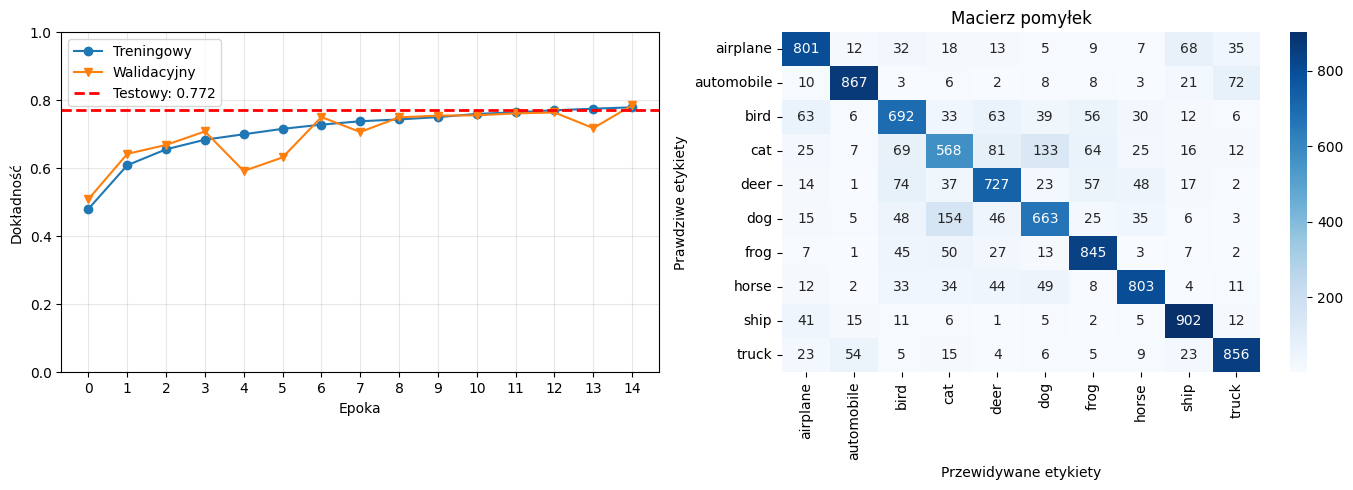

In [28]:
# Zmniejszamy rozmiar batcha do 32
cnn_BN_Drop_all = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop_all.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop_all.summary()

# Trening modelu
cnn_BN_Drop_all_hist= cnn_BN_Drop_all.fit(train_images, train_labels,
                     epochs=15, batch_size=32,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop_all, historia = cnn_BN_Drop_all_hist)

W przypadku zmniejszenia rozmiaru porcji danych, model charakteryzuje się dość dobrą stabilnością i dokładnością już na samym początku procesu uczenia. Uzyskaliśmy też najwyższą dokładność na zbiorze testowym, w pierwszych 15 epokach, spośród rozważanych dotąd modeli.


# Przekształcenia danych wejściowych (transformacje obrazów)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,658 (373.66 KB)

 Trainable params: 95,274 (372.16 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.3617 - loss: 1.8558 - val_accuracy: 0.5580 - val_loss: 1.2514
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5105 - loss: 1.3653 - val_accuracy: 0.4574 - val_loss: 1.5739
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5591 - loss: 1.2433 - val_accuracy: 0.5552 - val_loss: 1.2914
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5872 - loss: 1.1716 - val_accuracy: 0.5990 - val_loss: 1.1325
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.6127 - loss: 1.1079 - val_accuracy: 0.6678 - val_loss: 0.9444
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6307 - loss: 1.0667 - val_accuracy: 0.6178 - val_loss: 1.0807
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6326 - loss: 1.0491 - val_accuracy: 0.6592 - val_loss: 0.9655
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.6410 -

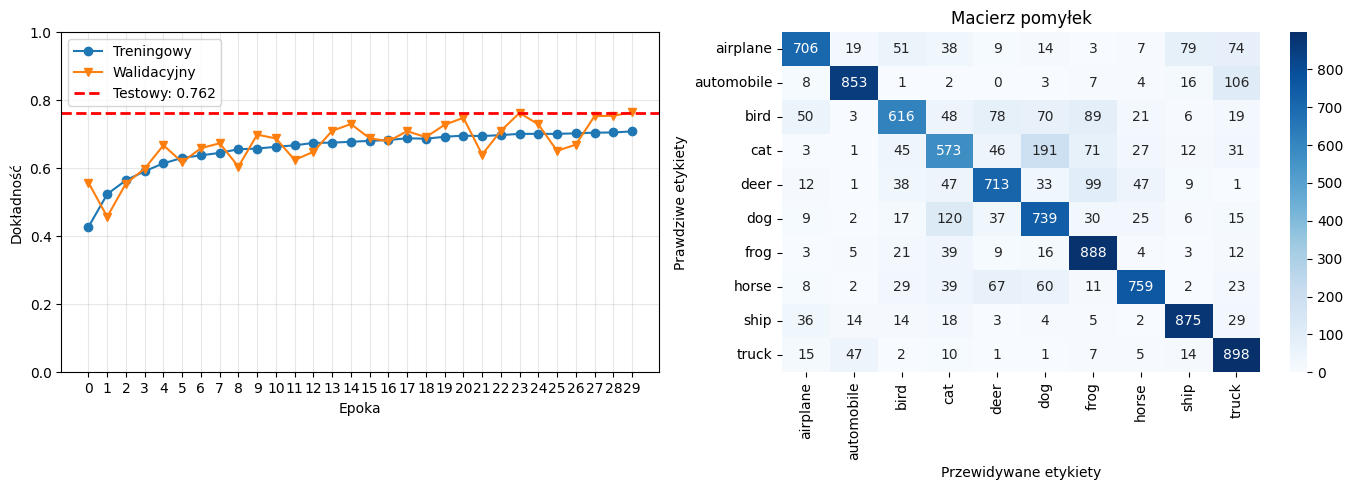

In [32]:
# Możemy dodać także transformacje na obrazach takie jak:
# obrót - RandomRotation()
# odbicie - RandomFlip()

cnn_BN_Drop_all_transform = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),
         layers.RandomFlip("horizontal"),
         layers.RandomRotation(0.1), # obrót o 1/10 * 360

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.MaxPooling2D((2, 2)),
         layers.BatchNormalization(),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),
         layers.Dense(10, activation='softmax')
        ])

cnn_BN_Drop_all_transform.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_BN_Drop_all_transform.summary()

# Trening modelu
cnn_BN_Drop_all_transform_hist= cnn_BN_Drop_all_transform.fit(train_images, train_labels,
                     epochs=30, batch_size=32,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_BN_Drop_all_transform, historia = cnn_BN_Drop_all_transform_hist)

Przekształcenie danych wejściowych nie poprawiło, a wręcz pogorszyło dokładność (wyniki dla 30 epok są gorsze niż dla 15 epok w przypadkach bez transformacji danych wejściowych). Również czas nauki w każdej z epok istotnie się wydłużył.

# Zmiana struktury sieci CNN
Zmieniamy strukturę warstw w sieci splotowej, sotsujemy Pooling po dwóch warstwach splotowych.
Po każdej warstwie splotowej stosujemy także Batch Normalization.

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_75 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 160,970 (628.79 KB)

 Trainable params: 160,266 (626.04 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.3498 - loss: 1.9507 - val_accuracy: 0.1960 - val_loss: 2.7406
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5998 - loss: 1.1367 - val_accuracy: 0.6190 - val_loss: 1.0816
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6743 - loss: 0.9198 - val_accuracy: 0.6328 - val_loss: 1.0621
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7222 - loss: 0.7906 - val_accuracy: 0.7286 - val_loss: 0.7877
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7506 - loss: 0.7134 - val_accuracy: 0.7312 - val_loss: 0.7657
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7749 - loss: 0.6501 - val_accuracy: 0.6810 - val_loss: 0.9532
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7931 - loss: 0.5966 - val_accuracy: 0.7480 - val_loss: 0.7356
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8053 - loss: 0.5555 - val_acc

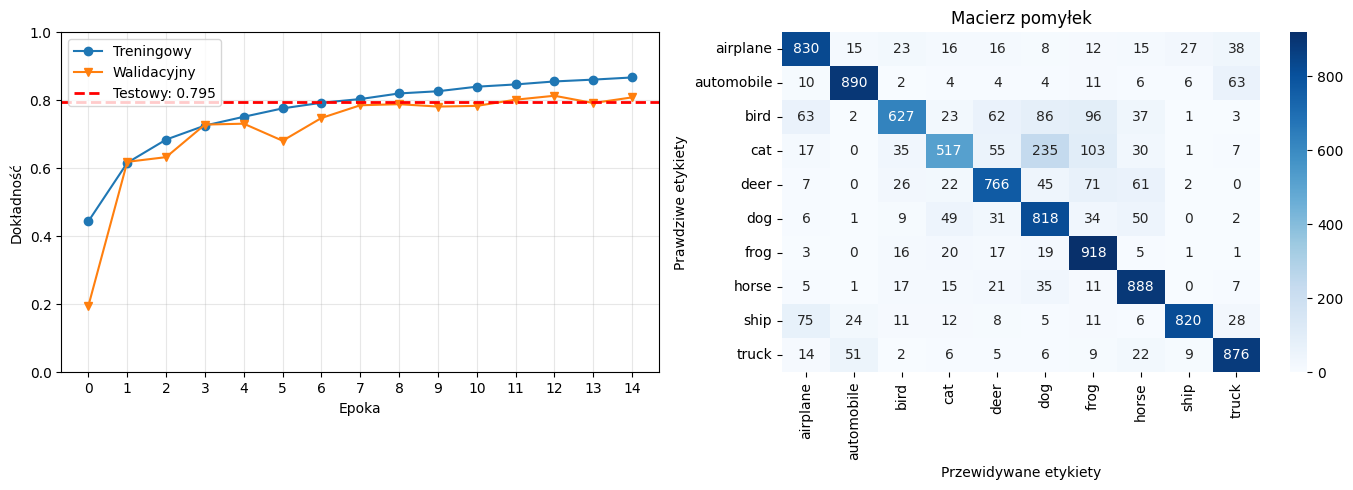

In [37]:
# Dodajemy w każdym bloku warstwę splotową z 32 filtrami (3,3) i paddingiem
# Po każdej warstwie splotowej stosujemy BN
cnn_best = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),
         layers.Dense(10, activation='softmax')
        ])

cnn_best.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_best.summary()

# Trening modelu
cnn_best_hist= cnn_best.fit(train_images, train_labels,
                     epochs=15, batch_size=128,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_best, historia = cnn_best_hist)

Uzyskujemy dokładność na zbiorze testowym bliską 80% (jednak liczba parametrów wzrosła dwuktornie wzlgędem bazowego modelu). Wykre dokładności modelu w danej epoce sugeruje dobrą stabilność modelu.

Wciąż, widoczny pozostaje problem błędnej klasyfykacji kota jako psa.

Eksperymentując dalej z powyższym modelem, udało się uzyskać dokładność na zbiorze testowym powyżej 80%.

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_105 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_107         │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_108         │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_109         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_110         │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_111         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_112         │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_113         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 339,626 (1.30 MB)

 Trainable params: 338,602 (1.29 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.3497 - loss: 1.8783 - val_accuracy: 0.5820 - val_loss: 1.1869
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5937 - loss: 1.1655 - val_accuracy: 0.6182 - val_loss: 1.0692
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6754 - loss: 0.9491 - val_accuracy: 0.7308 - val_loss: 0.7707
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7245 - loss: 0.8270 - val_accuracy: 0.7480 - val_loss: 0.7251
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7591 - loss: 0.7393 - val_accuracy: 0.7778 - val_loss: 0.6521
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7886 - loss: 0.6438 - val_accuracy: 0.7738 - val_loss: 0.6511
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8098 - loss: 0.5797 - val_accuracy: 0.8088 - val_loss: 0.5698
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8271 - loss: 0.5323 

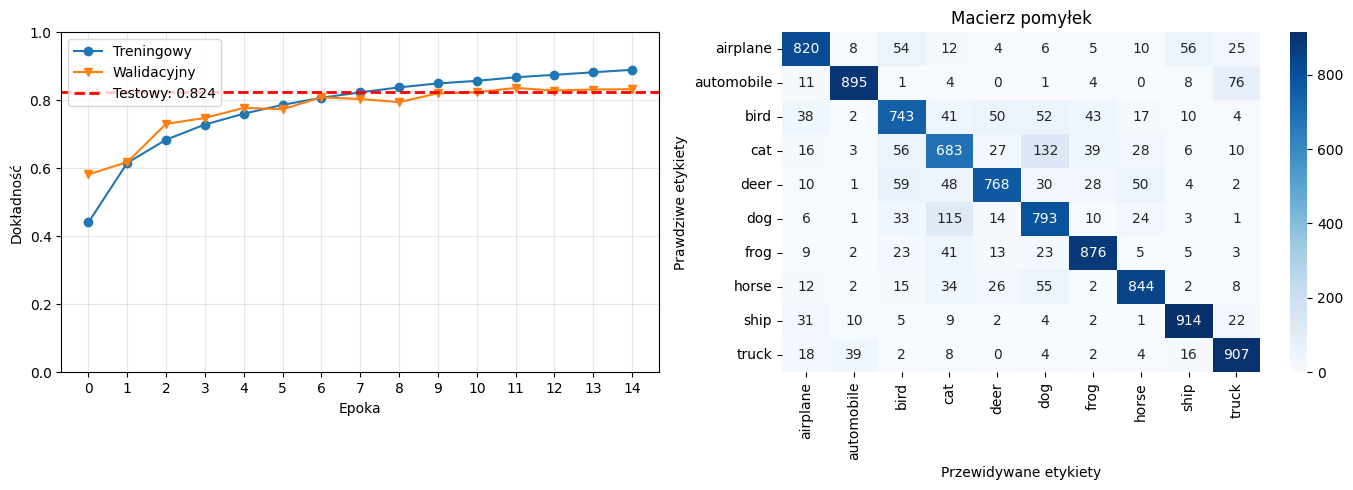

In [42]:
# Dodajemy w każdym bloku warstwę splotową z filtrami (3,3) i paddingiem
# Po każdej warstwie splotowej stosujemy BN

# Zwiększamy liczbę filtrów  w warstwach i dodajemy drugą warstwę gęstą
cnn_best = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),

         layers.Dense(32, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),

         layers.Dense(10, activation='softmax')
        ])

cnn_best.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_best.summary()

# Trening modelu
cnn_best_hist= cnn_best.fit(train_images, train_labels,
                     epochs=15, batch_size=32,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_best, historia = cnn_best_hist)

W 15 epokach udało się uzyskać wynik powyżej 80%, jednak model ma 4 razy więcej parametrów względem modelu bazowego.

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_171 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_195         │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_172 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_196         │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_96 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_141 (Dropout)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_173 (Conv2D)             │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_197         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_174 (Conv2D)             │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_198         │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_97 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_142 (Dropout)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_175 (Conv2D)             │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_199         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_176 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_200         │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_98 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_143 (Dropout)           │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_40 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_201         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 339,626 (1.30 MB)

 Trainable params: 338,602 (1.29 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.3388 - loss: 1.9010 - val_accuracy: 0.6152 - val_loss: 1.0897
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6065 - loss: 1.1420 - val_accuracy: 0.6798 - val_loss: 0.8954
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6822 - loss: 0.9406 - val_accuracy: 0.7244 - val_loss: 0.7843
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7238 - loss: 0.8260 - val_accuracy: 0.7492 - val_loss: 0.7157
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7621 - loss: 0.7199 - val_accuracy: 0.7938 - val_loss: 0.6014
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7864 - loss: 0.6593 - val_accuracy: 0.6918 - val_loss: 0.9220
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8085 - loss: 0.5864 - val_accuracy: 0.8138 - val_loss: 0.5648
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8198 - loss: 0.5468 

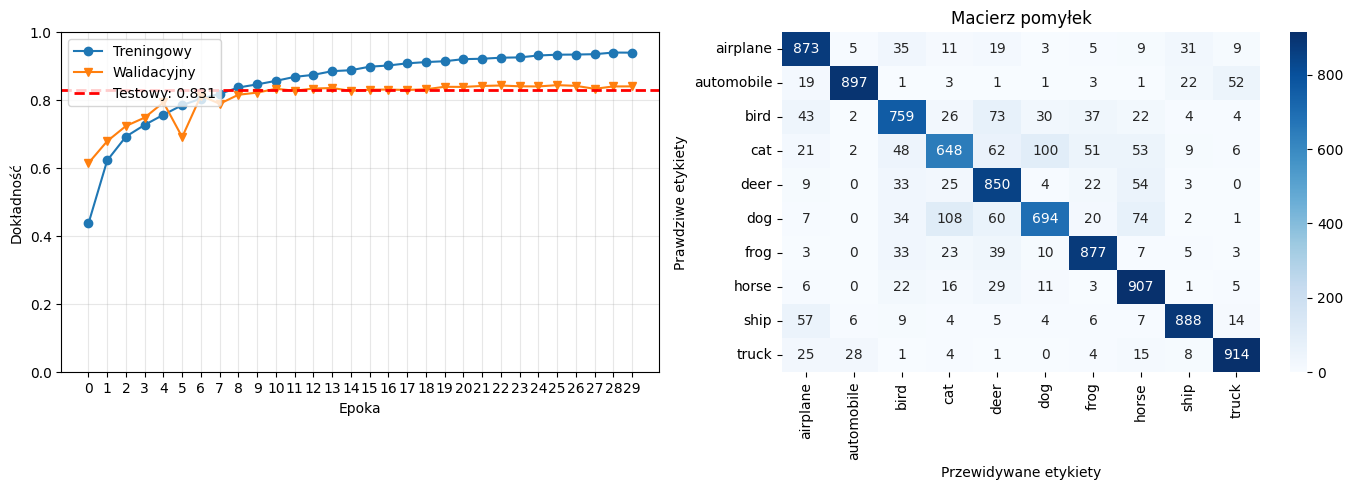

In [53]:
# Dodajemy w każdym bloku warstwę splotową z 32 filtrami (3,3) i paddingiem
# Po każdej warstwie splotowej stosujemy BN

# Zwiększamy liczbę filtrów  w warstwach i dodajemy drugą warstwę gęstą
cnn_best = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.1),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),

         layers.Dense(32, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.3),

         layers.Dense(10, activation='softmax')
        ])

cnn_best.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_best.summary()

# Trening modelu
cnn_best_hist= cnn_best.fit(train_images, train_labels,
                     epochs=30, batch_size=32,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_best, historia = cnn_best_hist)

Po 30 epokach model ten uzyskuje dokładność na poziomie 83%. Jest to niewielka poprawa względem 15 epok. Widoczna jest stała wartość dokładności klasyfikacji na zbiorze walidacyjnym po kilkunastu epokach.

Rozważmy prostszy model, z mniejszą liczbą filtrów, którego dokładność klasyfikacji po 30 epokach jest powyżej 80%.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 162,858 (636.16 KB)

 Trainable params: 162,090 (633.16 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.3275 - loss: 1.9086 - val_accuracy: 0.5844 - val_loss: 1.1497
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5738 - loss: 1.2046 - val_accuracy: 0.4558 - val_loss: 1.6495
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6524 - loss: 1.0033 - val_accuracy: 0.6870 - val_loss: 0.8801
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6986 - loss: 0.8807 - val_accuracy: 0.7506 - val_loss: 0.7150
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7213 - loss: 0.8184 - val_accuracy: 0.7184 - val_loss: 0.8189
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7459 - loss: 0.7534 - val_accuracy: 0.7480 - val_loss: 0.7218
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7620 - loss: 0.7079 - val_accuracy: 0.7922 - val_loss: 0.6024
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7790 - loss: 0.6563 

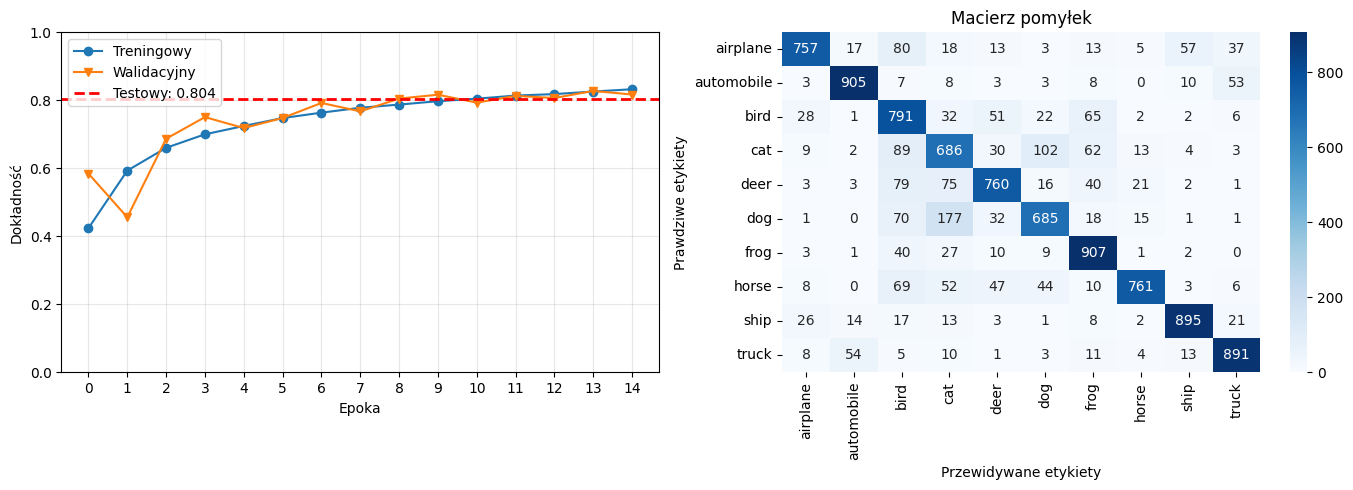

In [11]:

cnn_best = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),

         layers.Conv2D(32, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.2),

         layers.Conv2D(32, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.2),

         layers.Conv2D(32, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.2),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.2),

         layers.Dense(32, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.2),

         layers.Dense(10, activation='softmax')
        ])

cnn_best.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_best.summary()

# Trening modelu
cnn_best_hist= cnn_best.fit(train_images, train_labels,
                     epochs=15, batch_size=32,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_best, historia = cnn_best_hist)

Model posiada jedynie 2 razy więcej parametrów w porównaniu do modelu bazowego. Otrzymujemy jednak satysfakcjonujący wynik, niewiele gorszy od poprzedniego modelu.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 162,858 (636.16 KB)

 Trainable params: 162,090 (633.16 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.3252 - loss: 1.9056 - val_accuracy: 0.3980 - val_loss: 1.9016
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5764 - loss: 1.2009 - val_accuracy: 0.6206 - val_loss: 1.0749
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6603 - loss: 0.9879 - val_accuracy: 0.7202 - val_loss: 0.7964
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7019 - loss: 0.8707 - val_accuracy: 0.7310 - val_loss: 0.7637
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7319 - loss: 0.7936 - val_accuracy: 0.7526 - val_loss: 0.7417
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7478 - loss: 0.7406 - val_accuracy: 0.7818 - val_loss: 0.6333
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7664 - loss: 0.6981 - val_accuracy: 0.7786 - val_loss: 0.6609
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7852 - loss: 0.6449 

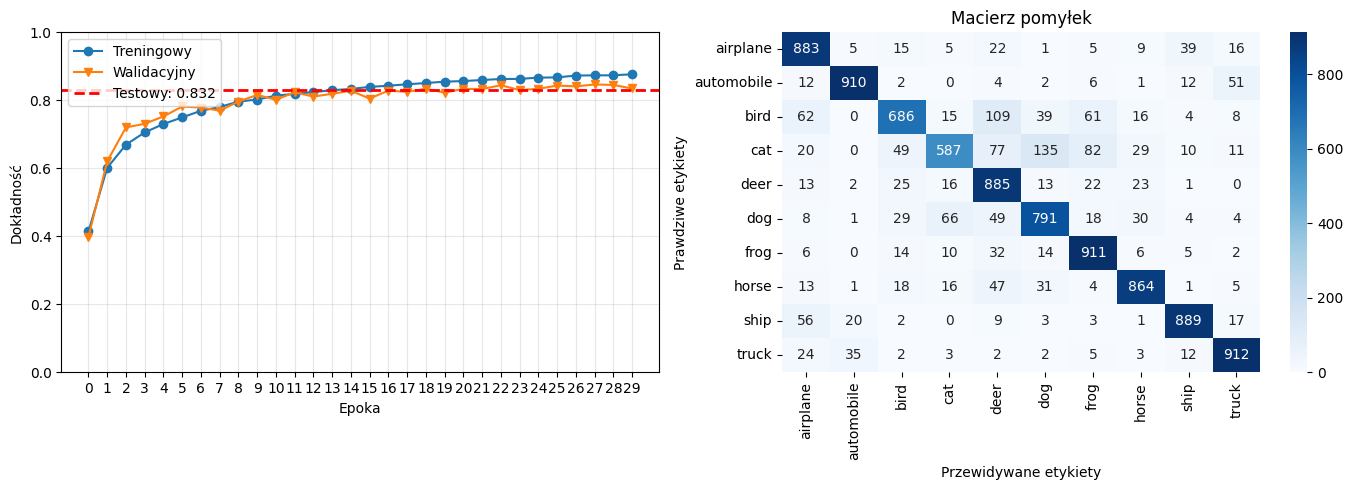

In [12]:

cnn_best = models.Sequential(
        [layers.Input(shape=(32, 32, 3)),

         layers.Conv2D(32, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.2),

         layers.Conv2D(32, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.2),

         layers.Conv2D(32, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.Conv2D(64, (3, 3), activation="relu", strides = 1, padding="same"),
         layers.BatchNormalization(),
         layers.MaxPooling2D((2, 2)),
         layers.Dropout(0.2),

         layers.Flatten(),
         layers.Dense(64, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.2),

         layers.Dense(32, activation="relu"),
         layers.BatchNormalization(),
         layers.Dropout(0.2),

         layers.Dense(10, activation='softmax')
        ])

cnn_best.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
cnn_best.summary()

# Trening modelu
cnn_best_hist= cnn_best.fit(train_images, train_labels,
                     epochs=30, batch_size=32,
                     validation_split=0.1)

rysuj_wyniki(model = cnn_best, historia = cnn_best_hist)

Kluczowe zatem okazało się zmiana struktury sieci. Dodanie bloków po dwie warstwy splotowe pozwoliło osiągnąć dokładność klasyfikacji powyżej 80 procent.
